In [1]:
import brushcue

START = (0, 0)
CONTROL = (500, 500)
END = (1000, 0)

path = brushcue.Path.new()
path = path.move_to_point(
    brushcue.Point2f.from_components(*START)
)
path = path.quadratic_bezier_to_point(
    brushcue.Point2f.from_components(*CONTROL),
    brushcue.Point2f.from_components(*END)
)

In [2]:
painter = brushcue.Painter.new()
render_style = brushcue.RenderStyle.brush_only(
    brushcue.Brush.solid(
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(1.0, 0.0, 0.0,  1.0)
        ),
        20
    )
)

control_polygon = brushcue.Path.new()
control_polygon = control_polygon.move_to_point(
    brushcue.Point2f.from_components(*START)
)
control_polygon = control_polygon.line_to_point(
    brushcue.Point2f.from_components(*CONTROL)
)
control_polygon = control_polygon.line_to_point(
    brushcue.Point2f.from_components(*END)
)
control_polygon_render_style = brushcue.RenderStyle.brush_only(
    brushcue.Brush.dashed(
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(0.45, 0.45, 0.45, 1.0)
        ),
        24,
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(0.45, 0.45, 0.45, 0.0)
        ),
        16,
        5
    )
)
painter = painter.add_path_with_render_style(path, render_style, brushcue.Transform2.identity().to_list())

painter = painter.add_path_with_render_style(
    control_polygon,
    control_polygon_render_style,
    brushcue.Transform2.identity().to_list()
)

POINT_DIAMETER = 40
point_render_style = brushcue.RenderStyle.fill_only(
    brushcue.Fill.solid(
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(0.15, 0.15, 0.15, 1.0)
        )
    )
)
for point in (START, CONTROL, END):
    painter = painter.add_ellipse_with_render_style(
        brushcue.Point2f.from_components(*point),
        brushcue.Vector2f.from_components(POINT_DIAMETER, POINT_DIAMETER),
        0,
        point_render_style,
        brushcue.Transform2.identity().to_list()
    )

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


Bounds(x=-20, y=-20, width=1040, height=540)


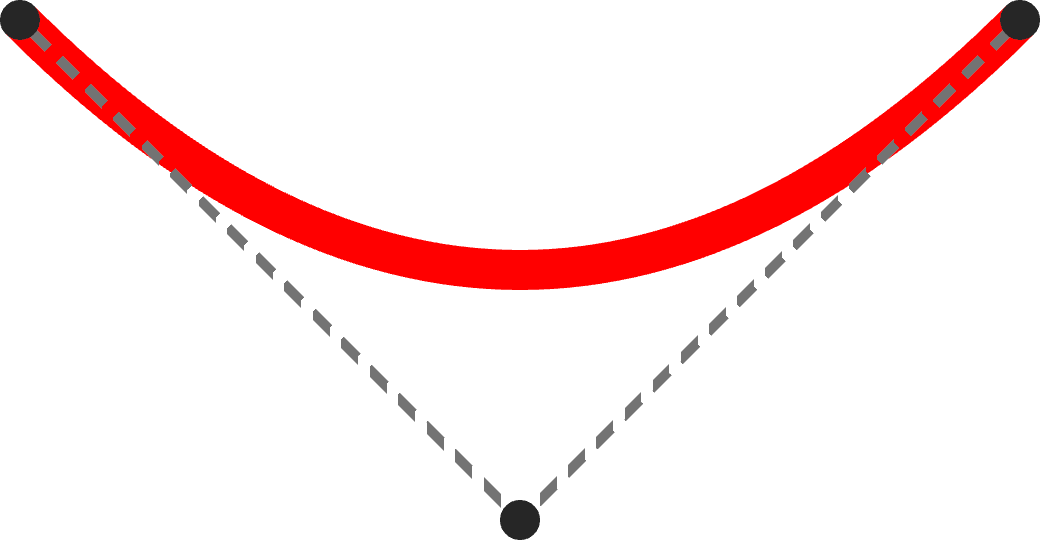

In [3]:
from IPython.display import Image, display

ctx = brushcue.Context()

composition = brushcue.Composition.painter(painter)
print(composition.bounds().execute(ctx))
display(Image(composition.execute(ctx).to_image_bytes(ctx)))